# 02 - Exploratory Data Analysis: Feature-Level Visualization

**Milestone 1 — Part 2.B**: Generate feature-level visualizations to understand distributions, detect outliers, and build intuition about the dataset.

## Objectives
- Generate histograms for **all** features (overview grid)
- Deep-dive into the **target** (`taxvaluedollarcnt`) and **3 other interesting features**
- Use appropriate plot types: histograms, boxplots (numerical), bar plots (categorical)
- Identify distributions (normal, skewed, exponential) and outliers

## Expected Outcomes
| Deliverable | Description |
|---|---|
| All-feature histogram grid | Quick overview of every column's distribution |
| 4 deep-dive plots | Target + 3 features with histograms + boxplots |
| Outlier observations | Notes on features with extreme values |
| Distribution labels | Normal / skewed / bimodal / etc. per explored feature |

## Mapping to Milestone 1
- **Part 2.B** — Feature-level visualization, discussion question 2.B

---

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

def dollar_format(x, pos):
    return f'${x:,.0f}'

df = pd.read_csv("zillow_dataset.csv")
print(f"Shape: {df.shape}")

Shape: (77613, 55)


## 1a. Categorical Histogram Grid

Quick overview — use a large `figsize` and `layout=(-1, m)` to get `m` columns with auto rows.

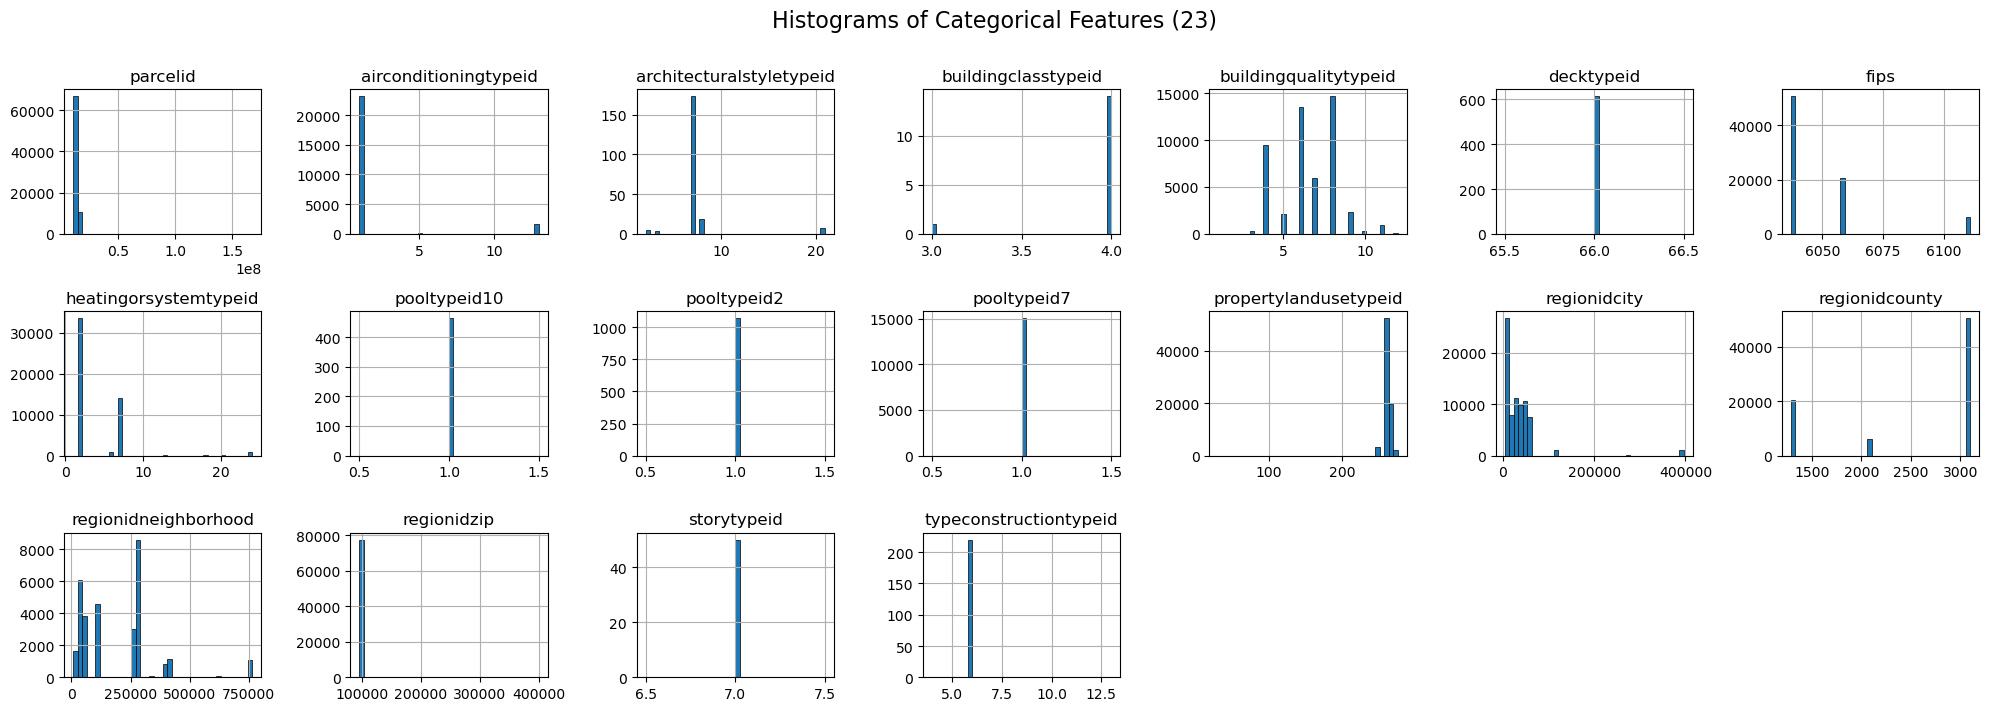

In [5]:
categorical = ['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'decktypeid', 'fips', 'hashottuborspa', 'heatingorsystemtypeid', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'storytypeid', 'typeconstructiontypeid', 'fireplaceflag', 'taxdelinquencyflag']

fig = df[categorical].hist(figsize=(20, 7), layout=(-1, 7), bins=40, edgecolor='black', linewidth=0.5)
plt.suptitle("Histograms of Categorical Features (23)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Non-boolean features**: parcelid, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqulitytypeid, fips, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzip

**Boolean**: pooltypeid10, pooltypeid2, poolytypeid7
Boolean but odd format: decktypeid and storytypeid look boolean but marked at 66 and 7 instead of 1.

<Axes: ylabel='typeconstructiontypeid'>

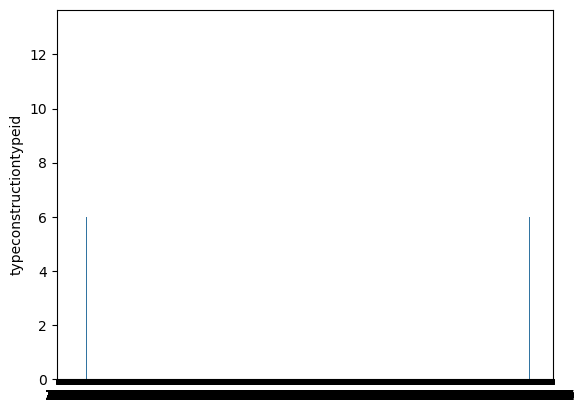

In [17]:
sns.barplot(df['typeconstructiontypeid'])

## 1a. Numerical Histogram Grid, Plus


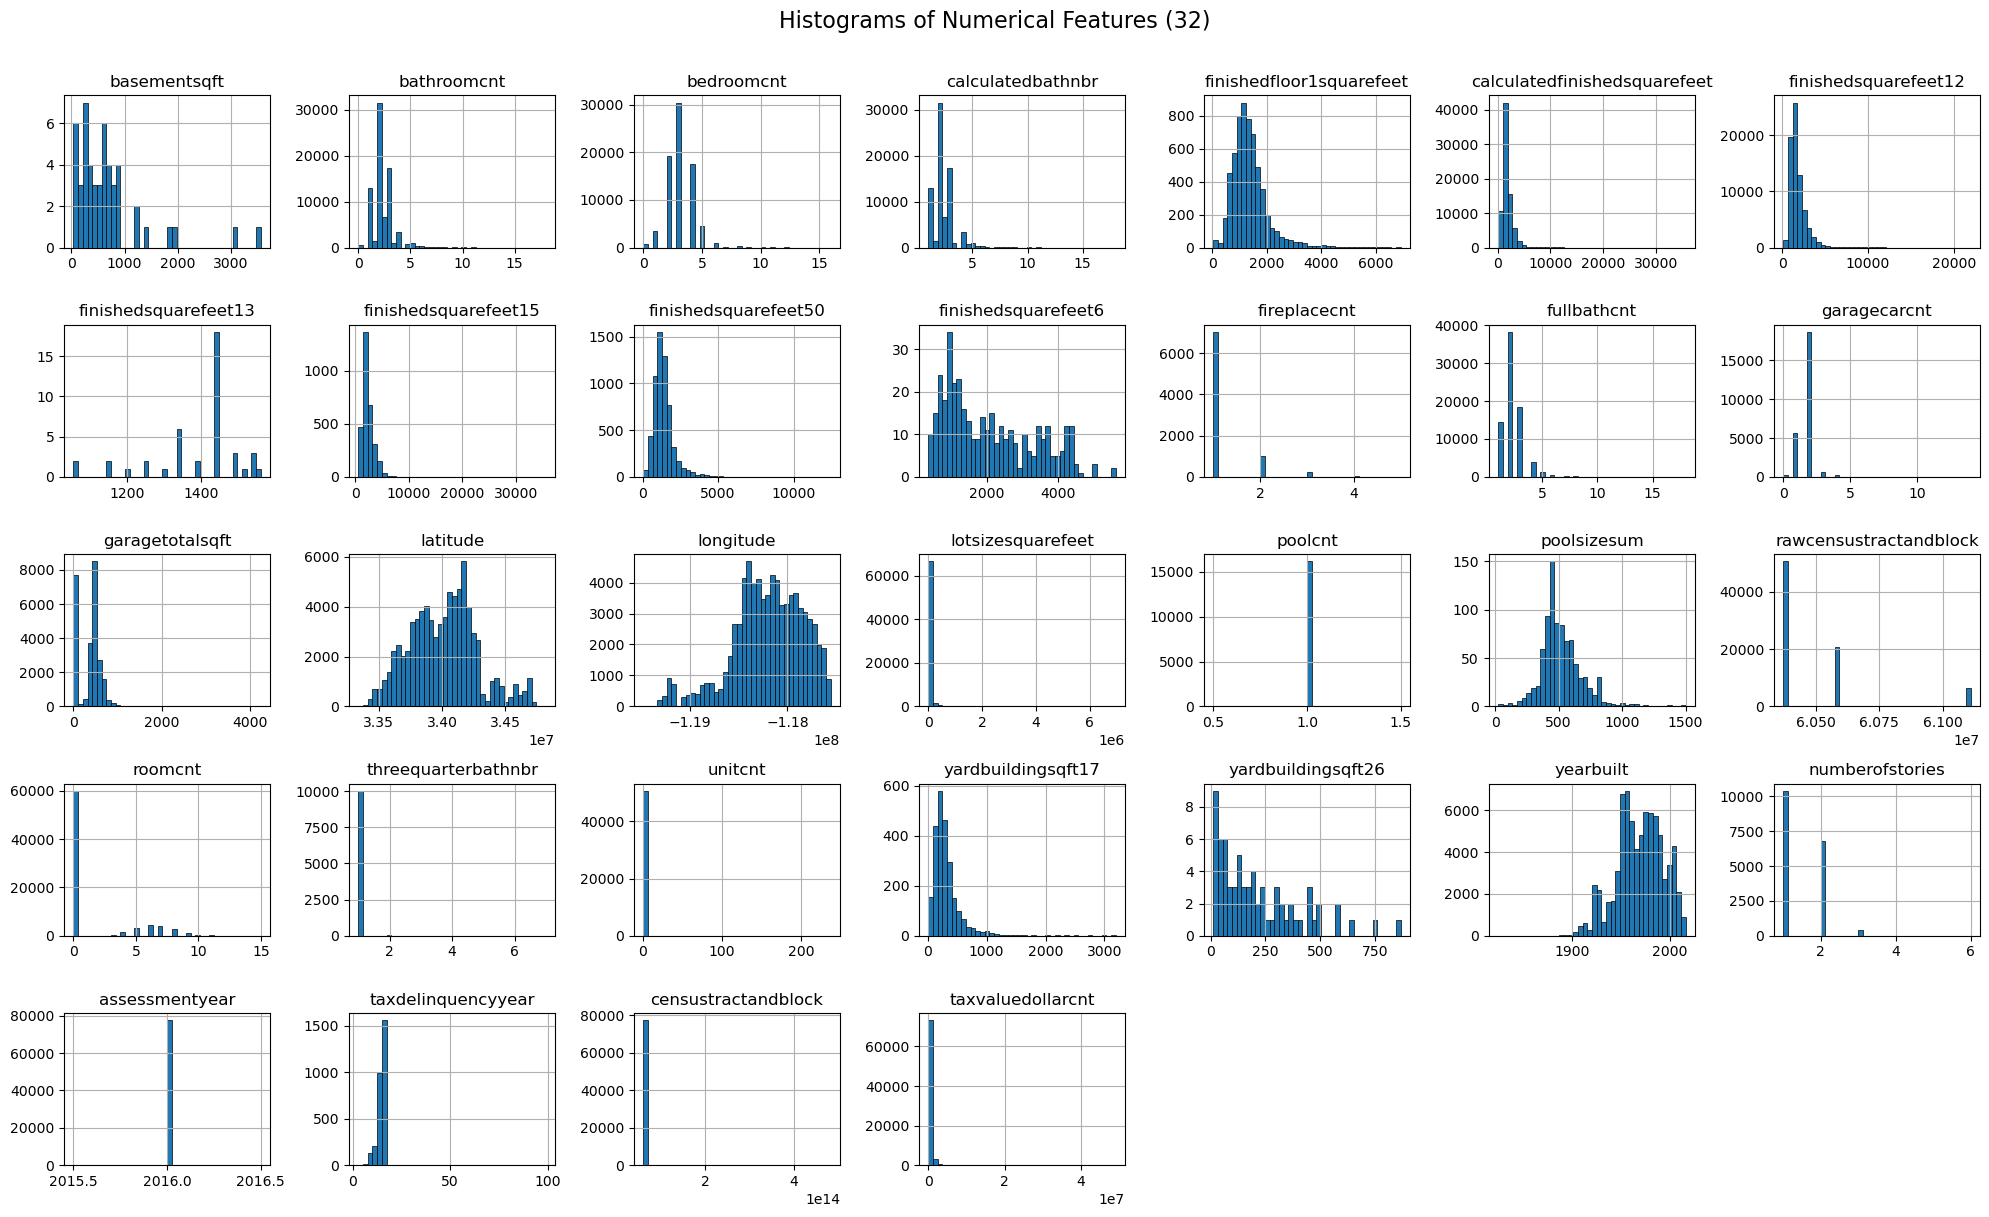

In [6]:
numerical =  ['basementsqft', 'bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'rawcensustractandblock', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'numberofstories', 'assessmentyear', 'taxdelinquencyyear', 'censustractandblock', 'taxvaluedollarcnt']

fig = df[numerical].hist(figsize=(20,12), layout=(-1, 7), bins=40, edgecolor='black', linewidth=0.5)
plt.suptitle("Histograms of Numerical Features (32)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

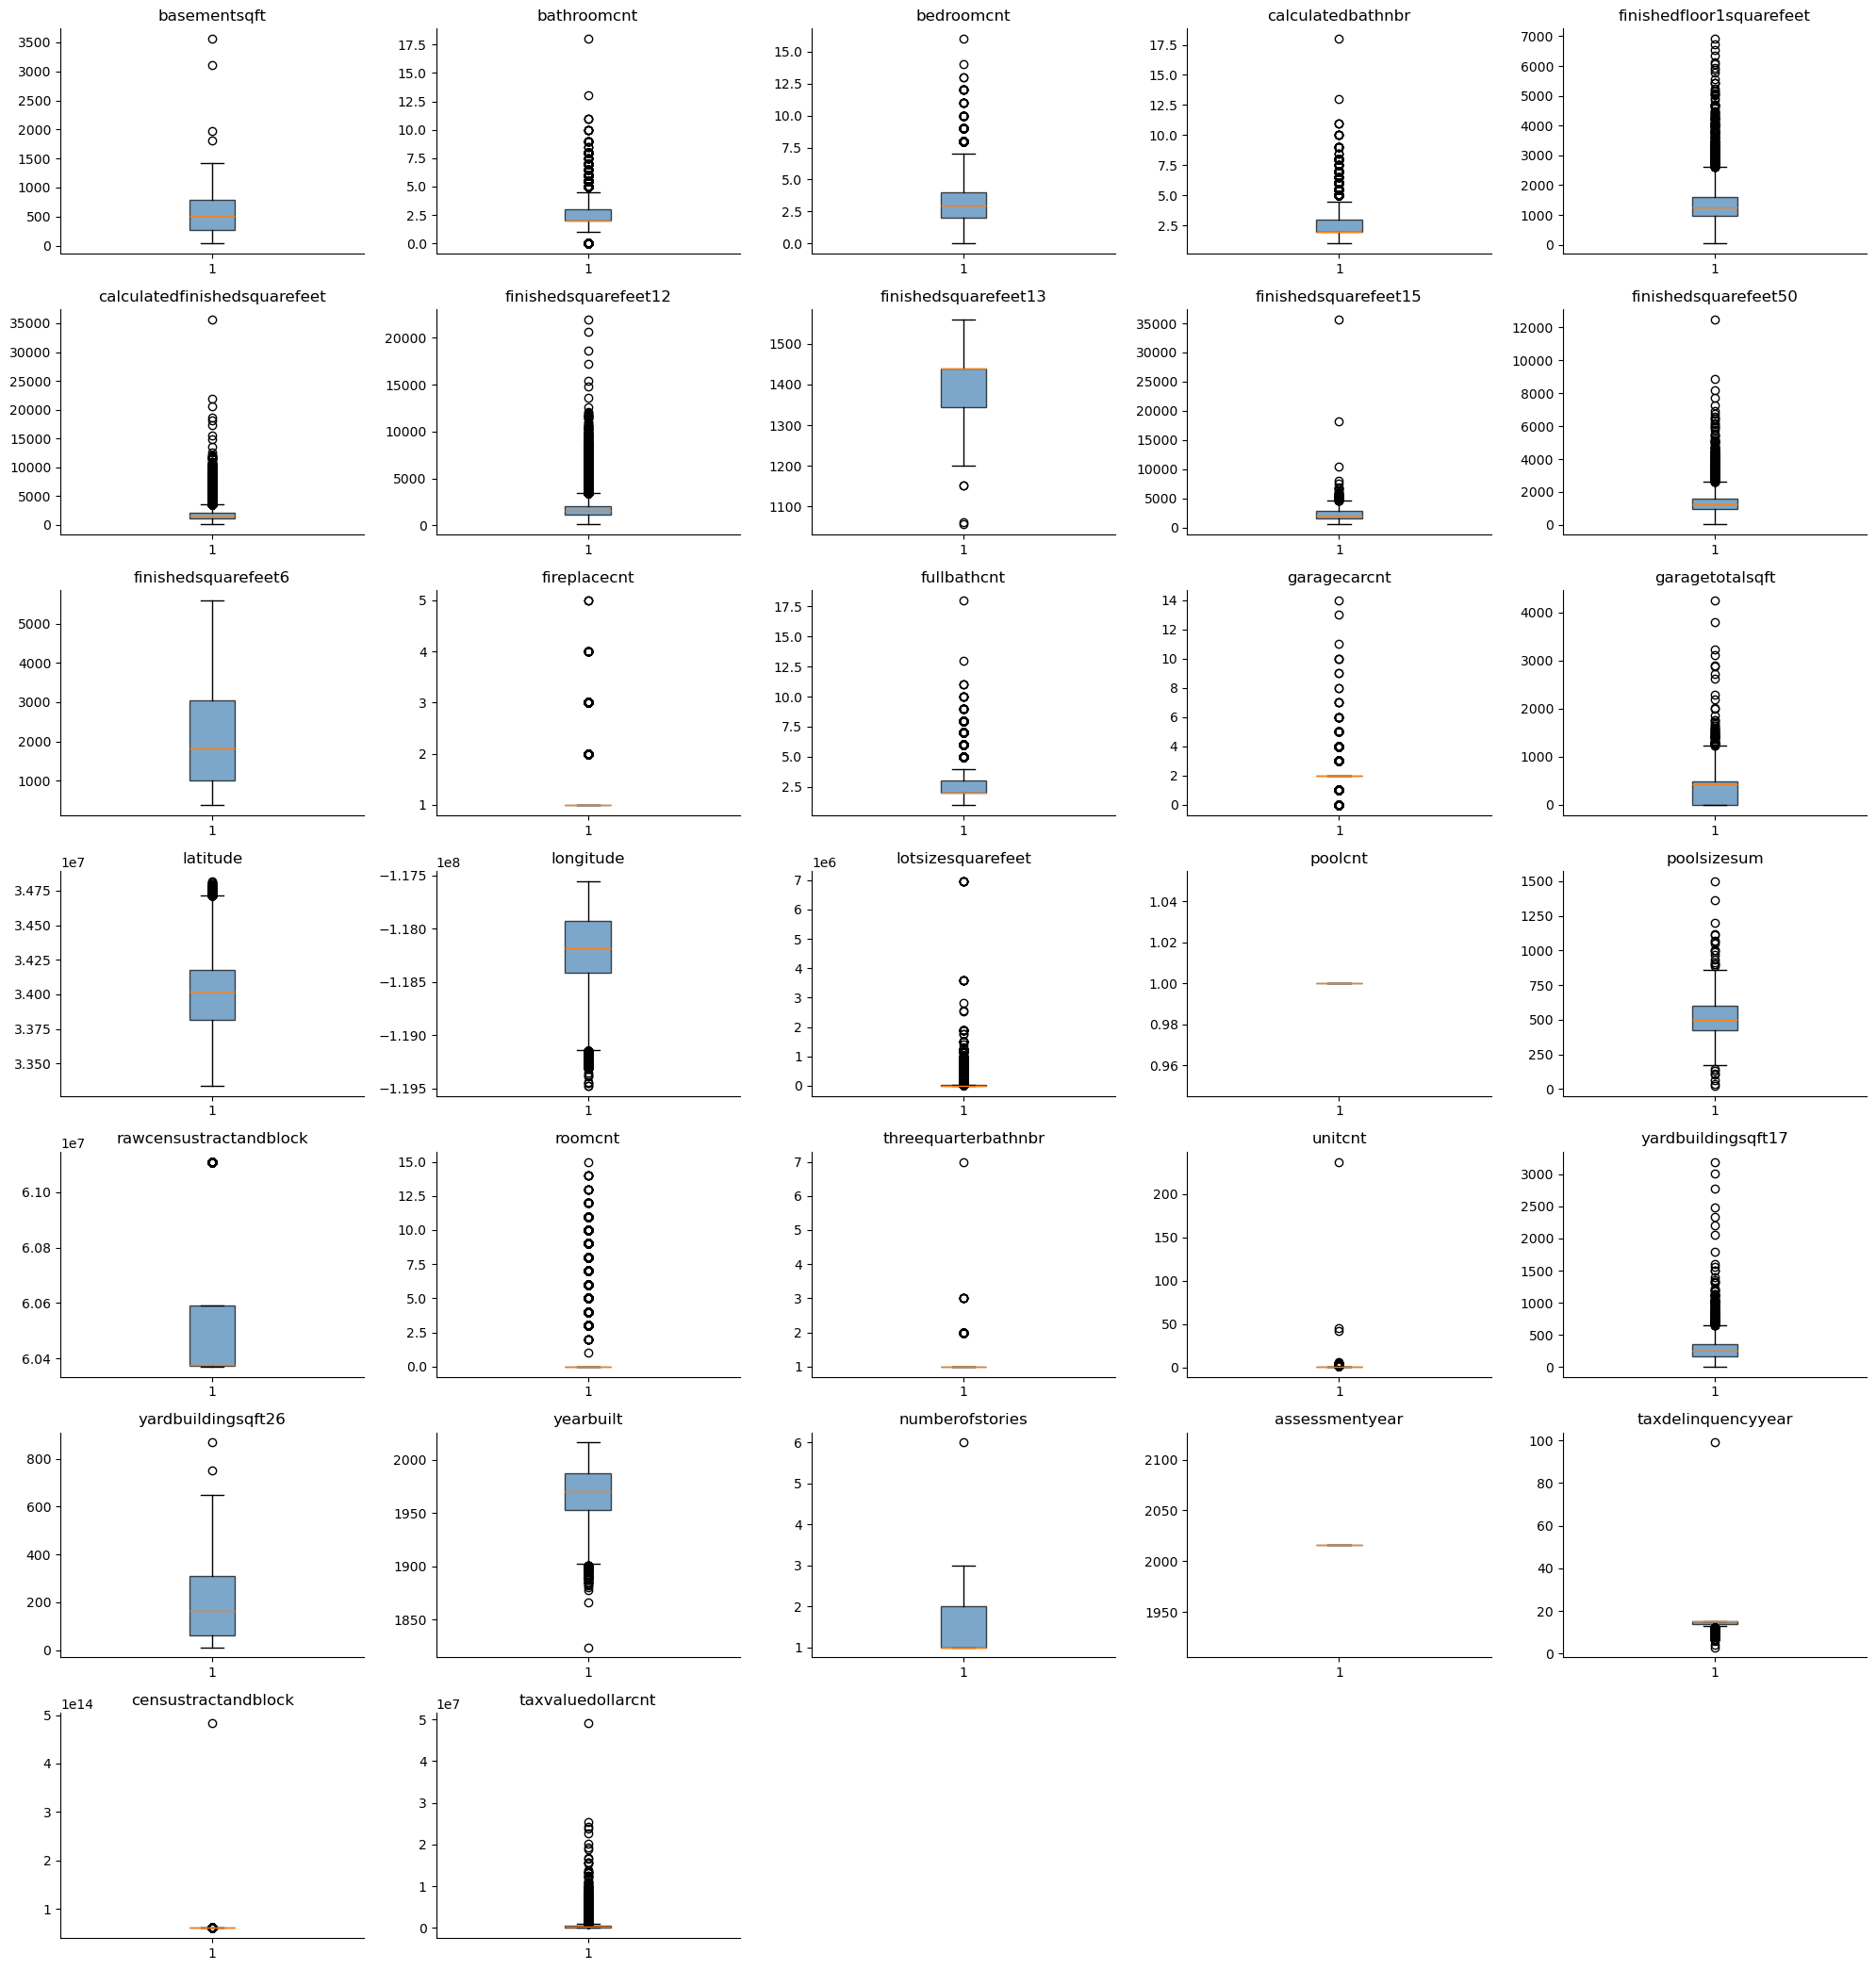

In [7]:
# Boxplots: 
n = len(numerical)
cols = 5
rows = -(-n // cols)  # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

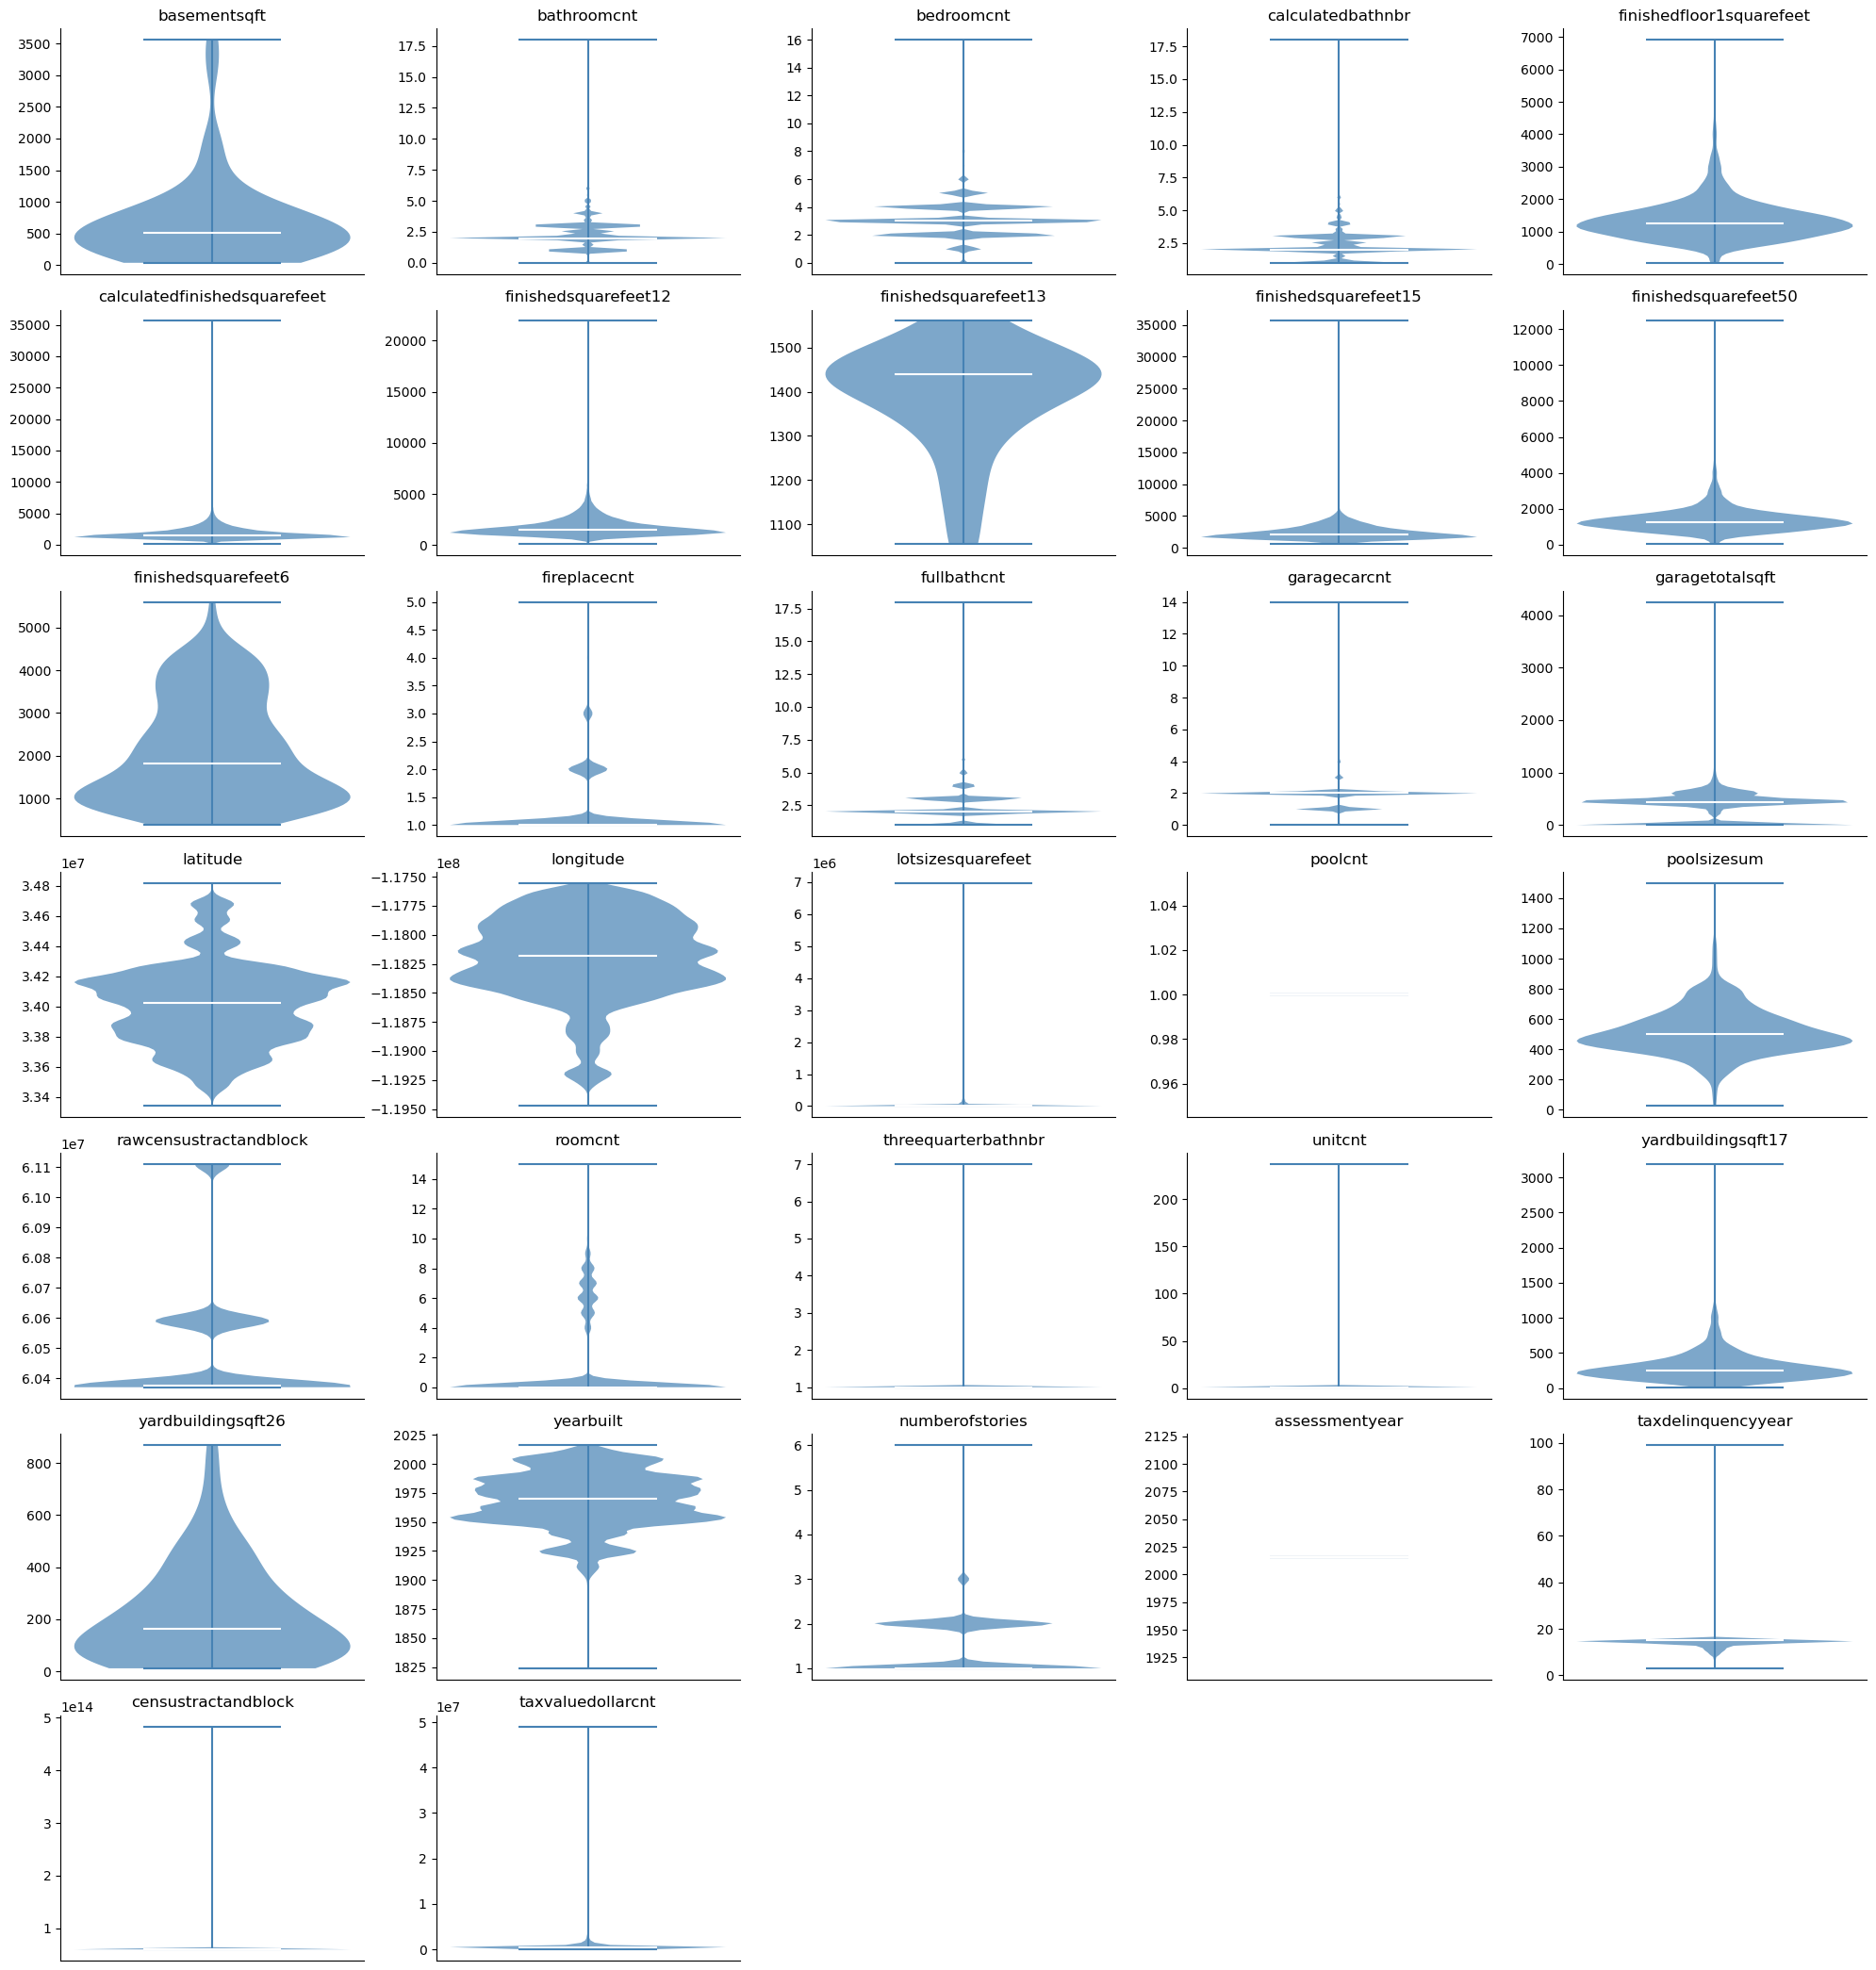

In [8]:
# Violinplots: 
n = len(numerical)
cols = 5
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical):
    parts = axes[i].violinplot(df[col].dropna(), showmedians=True)
    
    # Style the violin
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('white')
    parts['cmins'].set_color('steelblue')
    parts['cmaxes'].set_color('steelblue')
    parts['cbars'].set_color('steelblue')

    axes[i].set_title(col)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xticks([])  # x tick isn't meaningful for single violins

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

- **Target** (`taxvaluedollarcnt`): right skewed with many outliers, which should be removed in notebook 03
- **`finishedquarefeet`** have different skews and outliers. once cleaned or combined, outliers should be reexamined
- **`finishedquarefeet13`** and **`yearbuilt`** are the only left skewed numerical column (longitutde is left skewed but not significant)
- **`decktypeid`**: std = 0.0, all non-null values are 66 — a constant, confirmed later in the zero-variance analysis
- **`yardbuildingsquareft`** has multiple columns, both right skewed
- **`assessment year`** has only 1 value, can be dropped

## 2. Deep-Dive: Target Feature — `taxvaluedollarcnt`

The target variable deserves special attention: distribution shape, outliers, and range.

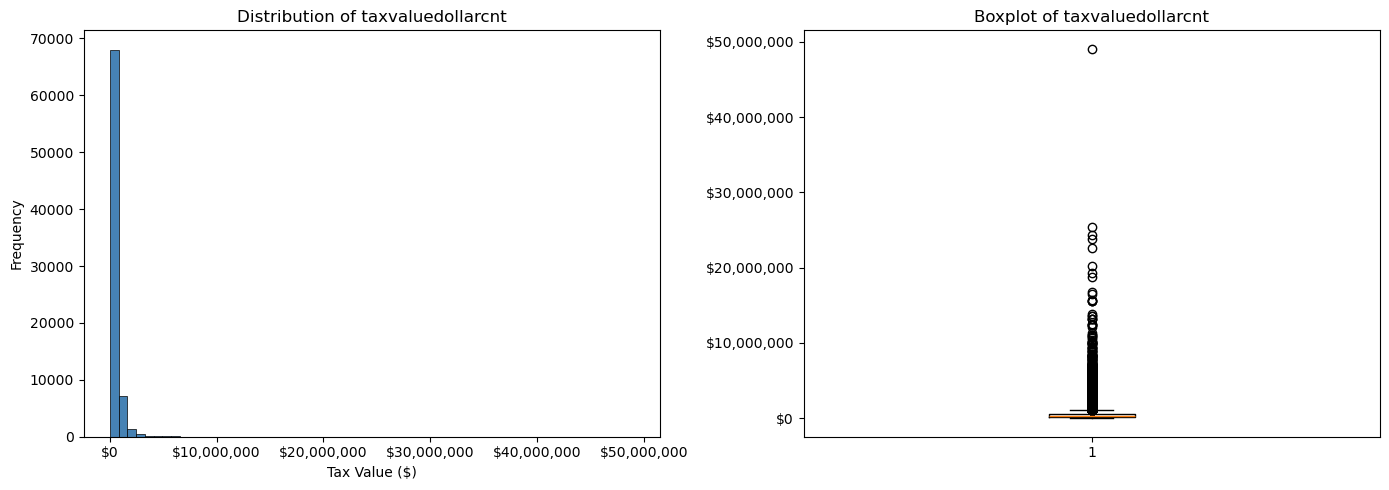

count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


In [9]:
target = "taxvaluedollarcnt"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[target].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f"Distribution of {target}")
axes[0].set_xlabel("Tax Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# Boxplot
axes[1].boxplot(df[target].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {target}")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

print(df[target].describe())

## 3. Deep-Dive: Feature 1

TODO: Pick an interesting numerical or categorical feature.

**Suggested candidates** (pick one):
- `calculatedfinishedsquarefeet` — total living area, strong predictor candidate
- `yearbuilt` — shows age distribution
- `lotsizesquarefeet` — lot size, potentially skewed

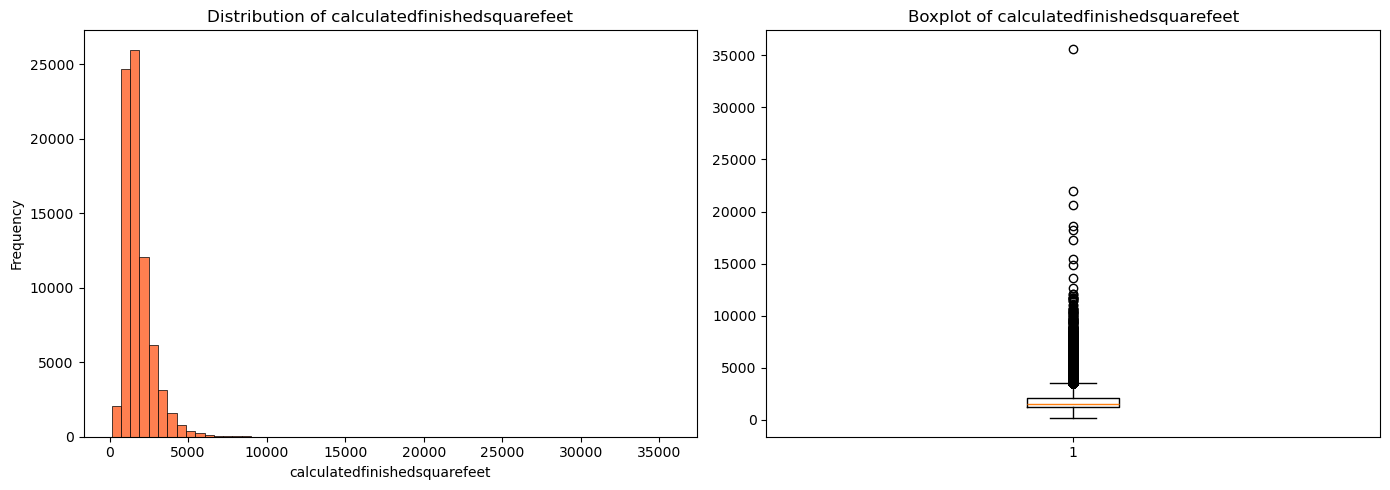

count    77378.000000
mean      1784.935421
std        954.250373
min        128.000000
25%       1182.000000
50%       1542.000000
75%       2112.000000
max      35640.000000
Name: calculatedfinishedsquarefeet, dtype: float64


In [10]:
# TODO: Replace with your chosen feature
feature_1 = "calculatedfinishedsquarefeet"  # <-- CHANGE IF DESIRED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[feature_1].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='coral')
axes[0].set_title(f"Distribution of {feature_1}")
axes[0].set_xlabel(feature_1)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df[feature_1].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_1}")

plt.tight_layout()
plt.show()

print(df[feature_1].describe())

In [ ]:
print(f"The maximum is {(35640 - 1784.935421)/954.250373:.2f} standard deviations away from the mean.")

The maximum is 35.48 standard deviations away from the mean.


In [40]:
largeft1 = (df[feature_1]>2112).sum()

print(f"{largeft1/len(df[feature_1])*100:.2f}% are outliers")

24.91% are outliers


## 4. Deep-Dive: Feature 2

TODO: Pick a second interesting feature.

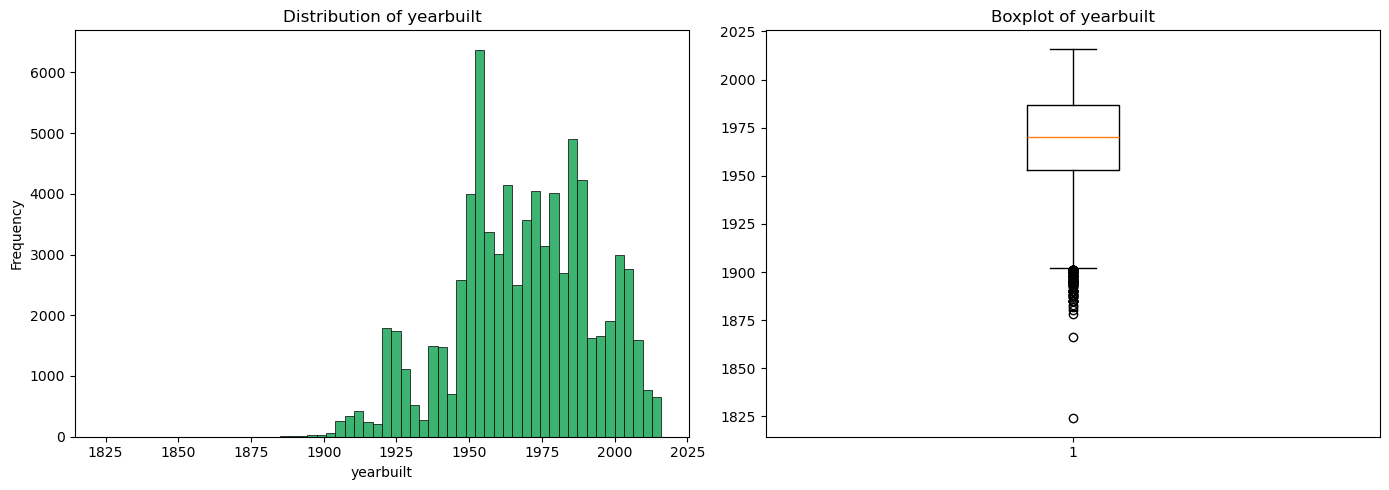

count    77309.000000
mean      1968.611507
std         23.793171
min       1824.000000
25%       1953.000000
50%       1970.000000
75%       1987.000000
max       2016.000000
Name: yearbuilt, dtype: float64


In [11]:
# TODO: Replace with your chosen feature
feature_2 = "yearbuilt"  # <-- CHANGE IF DESIRED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[feature_2].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='mediumseagreen')
axes[0].set_title(f"Distribution of {feature_2}")
axes[0].set_xlabel(feature_2)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df[feature_2].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_2}")

plt.tight_layout()
plt.show()

print(df[feature_2].describe())

In [37]:
print(f"The minimum is {-(1824 - 1968.611507)/23.793171:.2f} standard deviations away from the mean.")

The minimum is 6.08 standard deviations away from the mean.


In [41]:
smallft2 = (df[feature_2]<1953).sum()

print(f"{smallft2/len(df[feature_2])*100:.2f}% are outliers")

23.94% are outliers


## 5. Deep-Dive: Feature 3

TODO: Pick a third interesting feature. Consider a **categorical** one if you haven't yet.

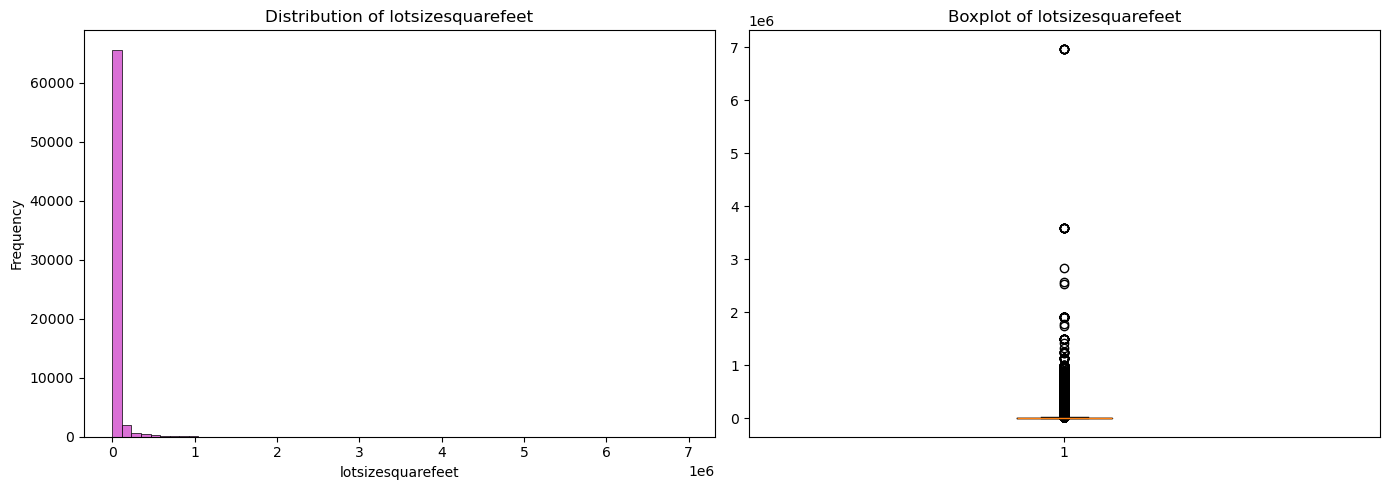

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64


In [12]:
# TODO: Replace with your chosen feature
feature_3 = "lotsizesquarefeet"  # <-- CHANGE IF DESIRED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[feature_3].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='orchid')
axes[0].set_title(f"Distribution of {feature_3}")
axes[0].set_xlabel(feature_3)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df[feature_3].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_3}")

plt.tight_layout()
plt.show()

print(df[feature_3].describe())

In [42]:
print(f"The maximum is {(6.971010e+06 - 2.997344e+04)/1.233050e+05:.2f} standard deviations away from the mean.")

The maximum is 56.29 standard deviations away from the mean.


In [44]:
largeft3 = (df[feature_3]>1.183700e+04).sum()

print(f"{largeft3 / len(df[feature_3])*100:.2f}% are outliers")

22.33% are outliers


---
## Discussion Question 2.B

Describe in a paragraph what you learned from your detailed examination:

### **Distribution type** (normal, exponential, skewed, bimodal)?

Most numerical columns are normal (and unimodal) with a right skew.
Only 3 numerical columns have a left skew, 2 of which are significant numerically: yearbuilt, taxdelinquencyyear.
Asessment year and pool count only have 1 possible value. Assessment year can be dropped since every value is 2016. Pool count has 1 or null, and the nulls can be imputed as 0, or the column dropped since the related column poolsizesum can represent existence of pool as well.

### **Problems** (outliers, odd characteristics)?
#### Categorical columns
**Non-boolean features**: parcelid, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqulitytypeid, fips, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzip

**Boolean**: pooltypeid10, pooltypeid2, poolytypeid7
Boolean but odd format: decktypeid and storytypeid look boolean but marked at 66 and 7 instead of 1.

#### Numerical columns
Evey numerical column except assessment year and pool count has outliers that will need to be removed in 03.
Many roomcnt values are 0, which is not be possible. Threequarterbathnbedroom also has many 0s, which is impossible, or the definition is different than expected.

#### **Why you chose each feature** and anything interesting?

1. **calculatedfinishedsquarefeet**: Contextually, finished square feet should be correlated to sale price and the target variable, tax value. It is extremely right-skewed. The maximum value is 35 standard deviations away from the mean, and almost 25% of the data fall into outlier range.

2. **yearbuilt**: Contextually, age of house is also typically related to sale price and therefore tax value. This is one of the only left skewed features, with outliers. The minimum value is 6 standard deviations away from the mean. 24% of the data are outliers.

3. **lotsizesquarefeet**: Similar to calculated finished square feet, overall lot size should be correlated to sale price and tax value. Again, this is extremely right skewed, the maximum value being 56 standard debiations away from the mean. 22% of the data are outliers. This feature may correlate with calculated finished square feet, which can be found in bivariate analysis.

---

### Next Notebook → `03_data_cleaning.ipynb`